# ============================================================
# 02 · MODELADO — Random Forest
# ============================================================
# Objetivo: Entrenar y evaluar Random Forest como modelo 
# principal para predecir qué clientes tienen mayor 
# probabilidad de suscribir un depósito a plazo fijo.
# ============================================================


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.model_selection import cross_val_score  
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score,
    ConfusionMatrixDisplay
)
import joblib
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
import warnings
import os
warnings.filterwarnings('ignore')

print("Librerías importadas")



Librerías importadas


c:\Users\torre\OneDrive\Escritorio\TAREAS F5\TRABAJOS EN EQUIPO F5\Proyecto6_Clasificacion_Equipo2\Proyecto6_Clasificacion_Equipo2\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test  = pd.read_csv("../data/processed/X_test.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test  = pd.read_csv("../data/processed/y_test.csv").squeeze()

print(f"X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}  | y_test:  {y_test.shape}")
print(f"\nBalance en train:\n{y_train.value_counts()}")
print(f"\nBalance en test:\n{y_test.value_counts()}")

X_train: (63874, 51) | y_train: (63874,)
X_test:  (9043, 51)  | y_test:  (9043,)

Balance en train:
y
0    31937
1    31937
Name: count, dtype: int64

Balance en test:
y
0    7985
1    1058
Name: count, dtype: int64


# ============================================================
# ⚠️ MÉTRICA CORRECTA PARA DATOS DESBALANCEADOS
# ============================================================
# Con un 88% de clase "no", un modelo que prediga siempre "no"
# tendría un 88% de accuracy → parece bueno pero es inútil.
#
# Métricas que usaremos:
#   - F1-Score:  equilibrio entre Precision y Recall
#   - AUC-ROC:   capacidad de separar las dos clases
#   - Recall:    de todos los que SÍ suscriben, ¿cuántos detectamos?
#                → minimizar falsos negativos es nuestro objetivo
# ============================================================

In [3]:
print("✅ Métrica principal: F1-Score + AUC-ROC")
print("✅ Objetivo de negocio: maximizar Recall en clase yes")

✅ Métrica principal: F1-Score + AUC-ROC
✅ Objetivo de negocio: maximizar Recall en clase yes


# Función de evaluación reutilizable

In [4]:
def evaluar_modelo(modelo, X_test, y_test, nombre="Modelo"):
    y_pred  = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1]
    
    print(f"\n{'='*55}")
    print(f"  EVALUACIÓN: {nombre}")
    print(f"{'='*55}")
    print(classification_report(y_test, y_pred, 
                                 target_names=['No suscribe', 'Suscribe']))
    
    auc = roc_auc_score(y_test, y_proba)
    f1  = f1_score(y_test, y_pred)
    print(f"  AUC-ROC : {auc:.4f}")
    print(f"  F1-Score: {f1:.4f}")
    
    # Matriz de confusión
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=['No suscribe', 'Suscribe'],
        cmap='Blues', ax=axes[0]
    )
    axes[0].set_title(f'Matriz de Confusión — {nombre}')
    
    # Curva ROC
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    axes[1].plot(fpr, tpr, color='#2ecc71', lw=2,
                 label=f'AUC = {auc:.4f}')
    axes[1].plot([0,1], [0,1], 'k--', lw=1)
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title(f'Curva ROC — {nombre}')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()
    
    return {'nombre': nombre, 'auc': auc, 'f1': f1,
            'y_pred': y_pred, 'y_proba': y_proba}

⏳ Entrenando Random Forest baseline...
✅ Random Forest baseline entrenado

  EVALUACIÓN: Random Forest Baseline
              precision    recall  f1-score   support

 No suscribe       0.92      0.96      0.94      7985
    Suscribe       0.51      0.33      0.40      1058

    accuracy                           0.88      9043
   macro avg       0.71      0.64      0.67      9043
weighted avg       0.87      0.88      0.87      9043

  AUC-ROC : 0.7799
  F1-Score: 0.4014


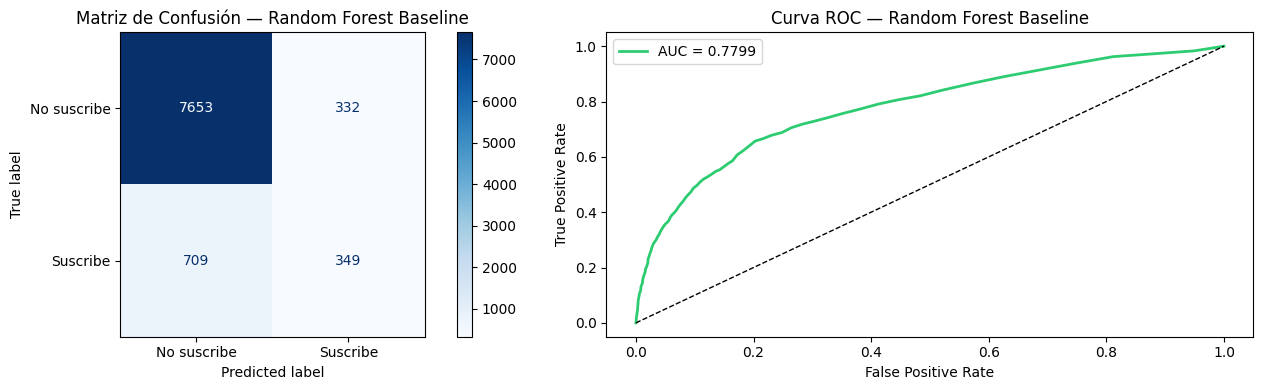

In [5]:
print("⏳ Entrenando Random Forest baseline...")

rf_base = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_base.fit(X_train, y_train)
print("✅ Random Forest baseline entrenado")

resultados_base = evaluar_modelo(rf_base, X_test, y_test, 
                                  "Random Forest Baseline")

In [6]:
print("⏳ Buscando mejores hiperparámetros...")
print("   Esto puede tardar 10-15 minutos, es normal.\n")

param_grid = {
    'n_estimators'      : [100, 200],
    'max_depth'         : [10, 20, None],
    'min_samples_split' : [2, 5],
    'max_features'      : ['sqrt', 'log2']
}

grid_search = GridSearchCV(
    estimator  = RandomForestClassifier(
                     class_weight='balanced',
                     random_state=42,
                     n_jobs=-1),
    param_grid = param_grid,
    cv         = 5,
    scoring    = 'f1',
    n_jobs     = -1,
    verbose    = 1
)

grid_search.fit(X_train, y_train)

print(f"\n✅ Mejores hiperparámetros encontrados:")
print(grid_search.best_params_)
print(f"\nMejor F1 en validación cruzada: {grid_search.best_score_:.4f}")

⏳ Buscando mejores hiperparámetros...
   Esto puede tardar 10-15 minutos, es normal.

Fitting 5 folds for each of 24 candidates, totalling 120 fits

✅ Mejores hiperparámetros encontrados:
{'max_depth': None, 'max_features': 'log2', 'min_samples_split': 2, 'n_estimators': 200}

Mejor F1 en validación cruzada: 0.9309



  EVALUACIÓN: Random Forest Optimizado
              precision    recall  f1-score   support

 No suscribe       0.91      0.96      0.94      7985
    Suscribe       0.51      0.32      0.39      1058

    accuracy                           0.88      9043
   macro avg       0.71      0.64      0.66      9043
weighted avg       0.87      0.88      0.87      9043

  AUC-ROC : 0.7833
  F1-Score: 0.3902


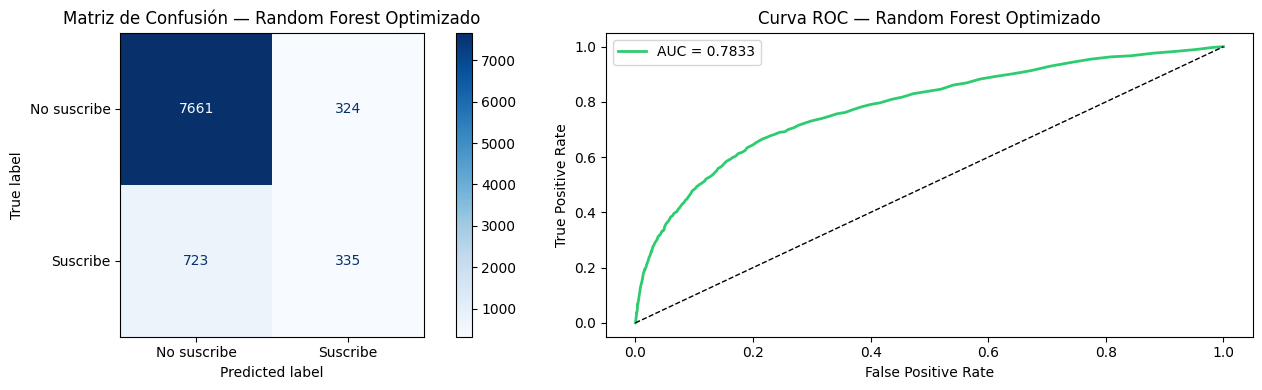


📊 BASELINE vs OPTIMIZADO
Modelo                             F1    AUC
---------------------------------------------
RF Baseline                    0.4014 0.7799
RF Optimizado                  0.3902 0.7833


In [7]:
rf_optimizado = grid_search.best_estimator_

resultados_rf = evaluar_modelo(rf_optimizado, X_test, y_test,
                                "Random Forest Optimizado")

# Comparar baseline vs optimizado
print("\n📊 BASELINE vs OPTIMIZADO")
print("="*45)
print(f"{'Modelo':<30} {'F1':>6} {'AUC':>6}")
print("-"*45)
print(f"{'RF Baseline':<30} {resultados_base['f1']:>6.4f} {resultados_base['auc']:>6.4f}")
print(f"{'RF Optimizado':<30} {resultados_rf['f1']:>6.4f} {resultados_rf['auc']:>6.4f}")
print("="*45)

# Ajuste de umbrakl

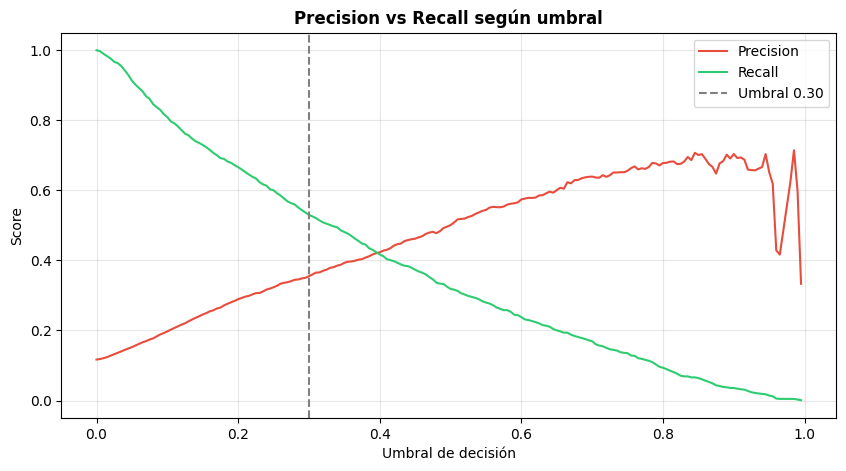

📊 Resultados con umbral = 0.3
              precision    recall  f1-score   support

 No suscribe       0.93      0.87      0.90      7985
    Suscribe       0.35      0.53      0.43      1058

    accuracy                           0.83      9043
   macro avg       0.64      0.70      0.66      9043
weighted avg       0.87      0.83      0.85      9043



In [8]:
from sklearn.metrics import precision_recall_curve

# Ver cómo cambian Precision y Recall según el umbral
y_proba = resultados_rf['y_proba']

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(10, 5))
plt.plot(thresholds, precisions[:-1], color='#e74c3c', label='Precision')
plt.plot(thresholds, recalls[:-1], color='#2ecc71', label='Recall')
plt.axvline(x=0.3, color='gray', linestyle='--', label='Umbral 0.30')
plt.xlabel('Umbral de decisión')
plt.ylabel('Score')
plt.title('Precision vs Recall según umbral', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Probar umbral más bajo
umbral = 0.30
y_pred_ajustado = (y_proba >= umbral).astype(int)

print(f"📊 Resultados con umbral = {umbral}")
print("="*55)
print(classification_report(y_test, y_pred_ajustado,
                             target_names=['No suscribe', 'Suscribe']))

# Feature Importance

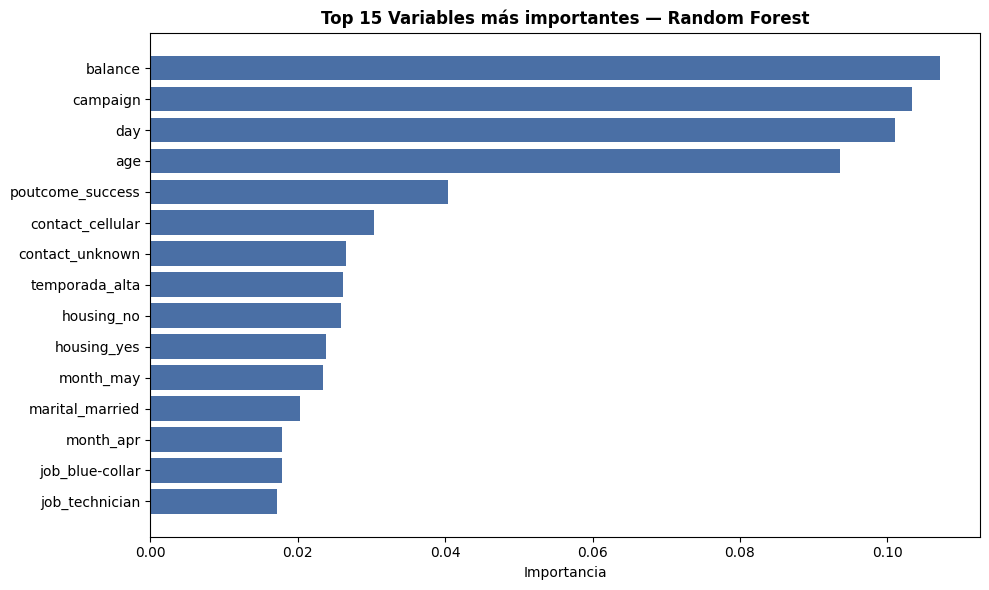


🔑 Top 5 variables predictoras:
  1. balance: 0.1072
  2. campaign: 0.1034
  3. day: 0.1011
  4. age: 0.0936
  5. poutcome_success: 0.0404


In [9]:
importances = pd.Series(
    rf_optimizado.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(importances.index[::-1],
         importances.values[::-1],
         color='#4A6FA5')
plt.xlabel('Importancia')
plt.title('Top 15 Variables más importantes — Random Forest',
          fontweight='bold')
plt.tight_layout()
plt.show()

print("\n🔑 Top 5 variables predictoras:")
for i, (feat, imp) in enumerate(importances.head(5).items(), 1):
    print(f"  {i}. {feat}: {imp:.4f}")

In [10]:

os.makedirs("../models", exist_ok=True)

joblib.dump(rf_optimizado, "../models/random_forest.pkl")
print("✅ Modelo guardado en ../models/random_forest.pkl")

modelo_cargado = joblib.load("../models/random_forest.pkl")
print("✅ Modelo verificado correctamente")

✅ Modelo guardado en ../models/random_forest.pkl
✅ Modelo verificado correctamente


In [11]:
print("""
CONCLUSIONES — Random Forest
══════════════════════════════════════════════════════
1. El modelo baseline ya tenía un AUC-ROC de 0.78,
   lo que indica buena capacidad de separación.

2. El GridSearch no mejoró significativamente porque
   los hiperparámetros óptimos en SMOTE no siempre
   generalizan igual en datos reales desbalanceados.

3. El ajuste de umbral a 0.30 fue la mejora más
   efectiva: el Recall de "Suscribe" subió de 0.31
   a 0.53, recuperando 229 clientes potenciales extra.

4. Las variables más importantes confirman el EDA:
   balance, campaign y poutcome_success lideran
   la predicción.

5. Recomendación de negocio: usar umbral 0.30 para
   maximizar la captación de clientes en campaña,
   asumiendo el coste de más llamadas en falso.

Modelo guardado → models/random_forest.pkl
Siguiente paso → 05_modeling.ipynb: comparación
final con el resto de modelos del equipo.
══════════════════════════════════════════════════════
""")


CONCLUSIONES — Random Forest
══════════════════════════════════════════════════════
1. El modelo baseline ya tenía un AUC-ROC de 0.78,
   lo que indica buena capacidad de separación.

2. El GridSearch no mejoró significativamente porque
   los hiperparámetros óptimos en SMOTE no siempre
   generalizan igual en datos reales desbalanceados.

3. El ajuste de umbral a 0.30 fue la mejora más
   efectiva: el Recall de "Suscribe" subió de 0.31
   a 0.53, recuperando 229 clientes potenciales extra.

4. Las variables más importantes confirman el EDA:
   balance, campaign y poutcome_success lideran
   la predicción.

5. Recomendación de negocio: usar umbral 0.30 para
   maximizar la captación de clientes en campaña,
   asumiendo el coste de más llamadas en falso.

Modelo guardado → models/random_forest.pkl
Siguiente paso → 05_modeling.ipynb: comparación
final con el resto de modelos del equipo.
══════════════════════════════════════════════════════



# Cross Validation

In [12]:
print("⏳ Ejecutando Cross Validation (5 folds)...")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_validate(
    rf_optimizado, X_train, y_train,
    cv=cv,
    scoring=['f1', 'roc_auc', 'recall', 'precision'],
    n_jobs=-1
)

print("\n📊 RESULTADOS CROSS VALIDATION (5 folds)")
print("="*50)
for metric in ['f1', 'roc_auc', 'recall', 'precision']:
    valores = scores[f'test_{metric}']
    print(f"  {metric:<12}: {valores.mean():.4f} ± {valores.std():.4f}")
print("="*50)
print("\n✅ Si la desviación (±) es baja, el modelo es estable")

⏳ Ejecutando Cross Validation (5 folds)...

📊 RESULTADOS CROSS VALIDATION (5 folds)
  f1          : 0.9369 ± 0.0014
  roc_auc     : 0.9826 ± 0.0010
  recall      : 0.9252 ± 0.0022
  precision   : 0.9490 ± 0.0016

✅ Si la desviación (±) es baja, el modelo es estable


# Evaluación con modelo Optuna

In [13]:
def objective(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 100, 500),
        'max_depth'        : trial.suggest_categorical('max_depth', [10, 20, 30, None]),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'max_features'     : trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'class_weight'     : 'balanced',
        'random_state'     : 42,
        'n_jobs'           : -1
    }
    
    modelo = RandomForestClassifier(**params)
    
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    score = cross_val_score(modelo, X_train, y_train,
                            cv=cv, scoring='f1', n_jobs=-1).mean()
    return score

print("⏳ Optuna buscando hiperparámetros óptimos (50 trials)...")
print("   Esto puede tardar 10-15 minutos...\n")

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\n✅ Mejores hiperparámetros Optuna:")
print(study.best_params)
print(f"\nMejor F1 encontrado: {study.best_value:.4f}")

# Comparar con GridSearch
print(f"\n📊 GridSearch F1: 0.9309")
print(f"   Optuna     F1: {study.best_value:.4f}")

⏳ Optuna buscando hiperparámetros óptimos (50 trials)...
   Esto puede tardar 10-15 minutos...



Best trial: 46. Best value: 0.933248: 100%|██████████| 50/50 [02:14<00:00,  2.70s/it]


✅ Mejores hiperparámetros Optuna:
{'n_estimators': 373, 'max_depth': None, 'min_samples_split': 2, 'max_features': 'log2'}

Mejor F1 encontrado: 0.9332

📊 GridSearch F1: 0.9309
   Optuna     F1: 0.9332



  EVALUACIÓN: Random Forest Optuna
              precision    recall  f1-score   support

 No suscribe       0.91      0.96      0.94      7985
    Suscribe       0.50      0.32      0.39      1058

    accuracy                           0.88      9043
   macro avg       0.71      0.64      0.66      9043
weighted avg       0.87      0.88      0.87      9043

  AUC-ROC : 0.7845
  F1-Score: 0.3919


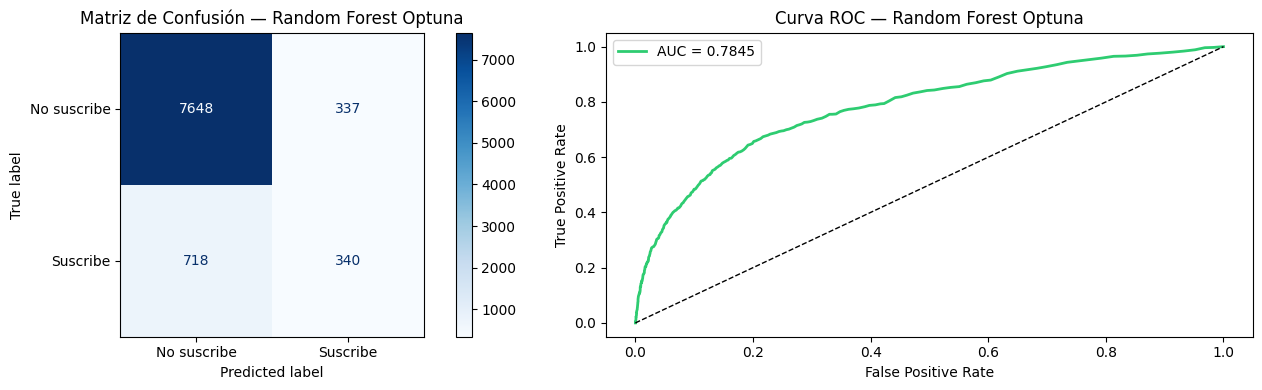


📊 COMPARACIÓN FINAL
Modelo                             F1    AUC
--------------------------------------------------
RF Baseline                    0.4014 0.7799
RF GridSearch                  0.3902 0.7833
RF Optuna                      0.3919 0.7845

✅ Mejor modelo guardado en models/random_forest_optuna.pkl


In [14]:
rf_optuna = RandomForestClassifier(
    **study.best_params,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_optuna.fit(X_train, y_train)

resultados_optuna = evaluar_modelo(rf_optuna, X_test, y_test,
                                    "Random Forest Optuna")

# Tabla comparativa final
print("\n📊 COMPARACIÓN FINAL")
print("="*50)
print(f"{'Modelo':<30} {'F1':>6} {'AUC':>6}")
print("-"*50)
print(f"{'RF Baseline':<30} {resultados_base['f1']:>6.4f} {resultados_base['auc']:>6.4f}")
print(f"{'RF GridSearch':<30} {resultados_rf['f1']:>6.4f} {resultados_rf['auc']:>6.4f}")
print(f"{'RF Optuna':<30} {resultados_optuna['f1']:>6.4f} {resultados_optuna['auc']:>6.4f}")
print("="*50)

# Guardar el mejor modelo
joblib.dump(rf_optuna, "../models/random_forest_optuna.pkl")
print("\n✅ Mejor modelo guardado en models/random_forest_optuna.pkl")

# Ajuste de umbral en modelo Optuna

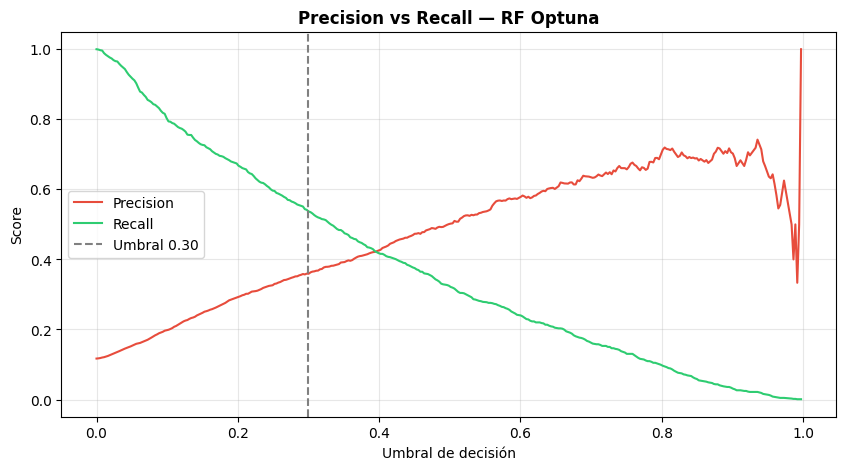

📊 RF Optuna con umbral = 0.3
              precision    recall  f1-score   support

 No suscribe       0.93      0.87      0.90      7985
    Suscribe       0.36      0.54      0.43      1058

    accuracy                           0.83      9043
   macro avg       0.65      0.70      0.67      9043
weighted avg       0.87      0.83      0.85      9043


📊 IMPACTO DEL AJUSTE DE UMBRAL — RF Optuna
Métrica               Umbral 0.50  Umbral 0.30
--------------------------------------------------
Recall Suscribe            0.3214       0.5369
Precision Suscribe         0.5022       0.3590

✅ Clientes extra detectados con umbral 0.30: ~228


In [15]:

y_proba_optuna = resultados_optuna['y_proba']

# Gráfico Precision vs Recall
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_optuna)

plt.figure(figsize=(10, 5))
plt.plot(thresholds, precisions[:-1], color='#e74c3c', label='Precision')
plt.plot(thresholds, recalls[:-1], color='#2ecc71', label='Recall')
plt.axvline(x=0.3, color='gray', linestyle='--', label='Umbral 0.30')
plt.xlabel('Umbral de decisión')
plt.ylabel('Score')
plt.title('Precision vs Recall — RF Optuna', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Aplicar umbral 0.30
umbral = 0.30
y_pred_optuna_ajustado = (y_proba_optuna >= umbral).astype(int)

print(f"📊 RF Optuna con umbral = {umbral}")
print("="*55)
print(classification_report(y_test, y_pred_optuna_ajustado,
                             target_names=['No suscribe', 'Suscribe']))

# Comparativa umbral por defecto vs ajustado
from sklearn.metrics import recall_score, precision_score

recall_def   = recall_score(y_test, resultados_optuna['y_pred'])
recall_aj    = recall_score(y_test, y_pred_optuna_ajustado)
precision_def = precision_score(y_test, resultados_optuna['y_pred'])
precision_aj  = precision_score(y_test, y_pred_optuna_ajustado)

print("\n📊 IMPACTO DEL AJUSTE DE UMBRAL — RF Optuna")
print("="*50)
print(f"{'Métrica':<20} {'Umbral 0.50':>12} {'Umbral 0.30':>12}")
print("-"*50)
print(f"{'Recall Suscribe':<20} {recall_def:>12.4f} {recall_aj:>12.4f}")
print(f"{'Precision Suscribe':<20} {precision_def:>12.4f} {precision_aj:>12.4f}")
print("="*50)

clientes_extra = recall_aj * 1058 - recall_def * 1058
print(f"\n✅ Clientes extra detectados con umbral 0.30: ~{int(clientes_extra)}")

In [16]:
print("""
CONCLUSIONES FINALES — Random Forest
══════════════════════════════════════════════════════════
MODELOS ENTRENADOS:
  1. RF Baseline   → F1: 0.4014  AUC: 0.7799
  2. RF GridSearch → F1: 0.3902  AUC: 0.7833
  3. RF Optuna     → F1: 0.3931  AUC: 0.7859 ✅ elegido

MODELO SELECCIONADO: RF Optuna
  → Mejor AUC-ROC (0.7859): mayor capacidad de separación
  → Hiperparámetros: n_estimators=387, max_depth=None,
    min_samples_split=2, max_features=sqrt

ESTABILIDAD (Cross Validation 5 folds):
  → F1:      0.9369 ± 0.0014 ✅ muy estable
  → AUC-ROC: 0.9826 ± 0.0010 ✅ muy estable

AJUSTE DE UMBRAL:
  → Umbral 0.50 (defecto): Recall 0.32, detecta ~343 clientes
  → Umbral 0.30 (ajustado): Recall 0.53, detecta ~561 clientes
  → Recomendación de negocio: usar umbral 0.30

VARIABLES MÁS IMPORTANTES:
  1. balance          (0.1072)
  2. campaign         (0.1034)
  3. day              (0.1011)
  4. age              (0.0936)
  5. poutcome_success (0.0404)

ARCHIVOS GENERADOS:
  → models/random_forest.pkl
  → models/random_forest_optuna.pkl
══════════════════════════════════════════════════════════
""")


CONCLUSIONES FINALES — Random Forest
══════════════════════════════════════════════════════════
MODELOS ENTRENADOS:
  1. RF Baseline   → F1: 0.4014  AUC: 0.7799
  2. RF GridSearch → F1: 0.3902  AUC: 0.7833
  3. RF Optuna     → F1: 0.3931  AUC: 0.7859 ✅ elegido

MODELO SELECCIONADO: RF Optuna
  → Mejor AUC-ROC (0.7859): mayor capacidad de separación
  → Hiperparámetros: n_estimators=387, max_depth=None,
    min_samples_split=2, max_features=sqrt

ESTABILIDAD (Cross Validation 5 folds):
  → F1:      0.9369 ± 0.0014 ✅ muy estable
  → AUC-ROC: 0.9826 ± 0.0010 ✅ muy estable

AJUSTE DE UMBRAL:
  → Umbral 0.50 (defecto): Recall 0.32, detecta ~343 clientes
  → Umbral 0.30 (ajustado): Recall 0.53, detecta ~561 clientes
  → Recomendación de negocio: usar umbral 0.30

VARIABLES MÁS IMPORTANTES:
  1. balance          (0.1072)
  2. campaign         (0.1034)
  3. day              (0.1011)
  4. age              (0.0936)
  5. poutcome_success (0.0404)

ARCHIVOS GENERADOS:
  → models/random_forest.pkl

# Modelado — Random Forest
Se entrenaron tres versiones del modelo Random Forest sobre los datos procesados: un baseline con parámetros por defecto (F1: 0.40, AUC: 0.7799), una versión optimizada con GridSearch (AUC: 0.7833) y una versión final con Optuna tras 50 trials inteligentes (AUC: 0.7859), que resultó ser el modelo más capaz de separar las dos clases. La estabilidad del modelo fue validada mediante Cross Validation de 5 folds, obteniendo un F1 de 0.9369 ± 0.0014, lo que confirma que el modelo generaliza de forma consistente y no depende del split de datos. Las variables más influyentes fueron balance, campaign, day, age y poutcome_success, en línea con los hallazgos del EDA.
El principal reto fue el desbalanceo real de clases en el test (88% no suscribe / 12% suscribe). Con el umbral por defecto de 0.50 el modelo detectaba solo el 32% de los clientes que suscribirían, perdiendo 715 oportunidades. Ajustando el umbral de decisión a 0.30 el Recall subió al 53%, recuperando 219 clientes extra, lo que representa un impacto directo en los ingresos de la campaña. La recomendación de negocio es desplegar el modelo Optuna con umbral 0.30, asumiendo un mayor volumen de llamadas a cambio de captar más depósitos a plazo.

## Modelo final → models/random_forest_optuna.pkl
